In [13]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix
from datacleaning import customer_handle_missing_values

from utils import (
    scaling,
    plot_dendrogram,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette
)

In [14]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.020065,0.012964,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.099442,0.002867,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.035694,0.098913,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.005618,0.137440,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.014730,0.080746,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0


In [15]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'year_first_transaction',
       'years_tenure', 'distinct_stores_visited', 'number_complaints',
       'typical_hour', 'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_ou

In [47]:
features = [
    'customer_age',
    'number_complaints',
    'total_children',
    'years_tenure',
    'distinct_stores_visited',


    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_spend_tech_entertainment',
    'perc_spend_hygiene',
]

X = dataset[features].copy()
X.columns

Index(['customer_age', 'number_complaints', 'total_children', 'years_tenure',
       'distinct_stores_visited', 'percentage_of_products_bought_promotion',
       'perc_spend_vegetables', 'perc_spend_meat_fish',
       'perc_spend_tech_entertainment', 'perc_spend_hygiene'],
      dtype='object')

In [48]:
# Depois faz o scaling normalmente
X_scaled = scaling(X)

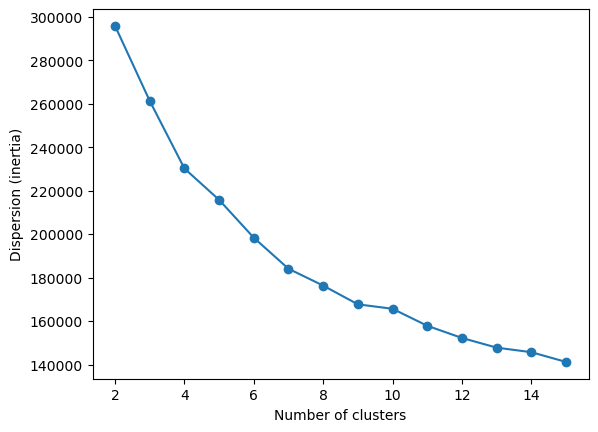

In [49]:
K_range = 15

inertias = []

for k in range(2, K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(experimental_kmeans.inertia_)

plt.plot(range(2, K_range+1), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

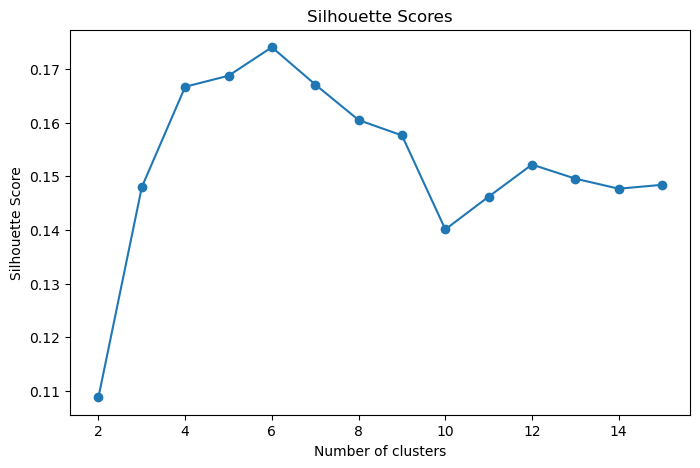

In [50]:
scores = []

for k in range(2,K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = experimental_kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

k=6 | silhouette=0.1741
k=7 | silhouette=0.1671
k=8 | silhouette=0.1605
k=9 | silhouette=0.1576
k=10 | silhouette=0.1401


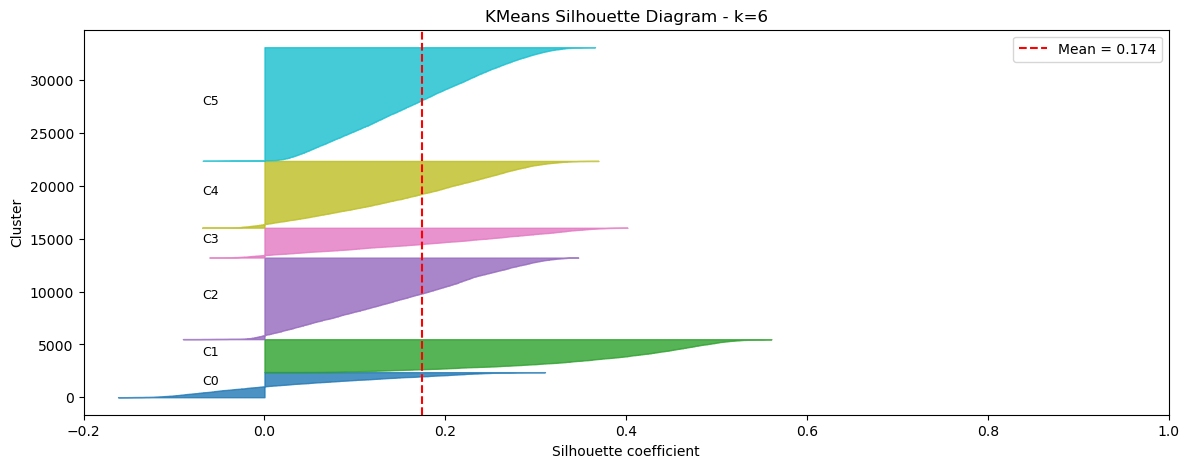

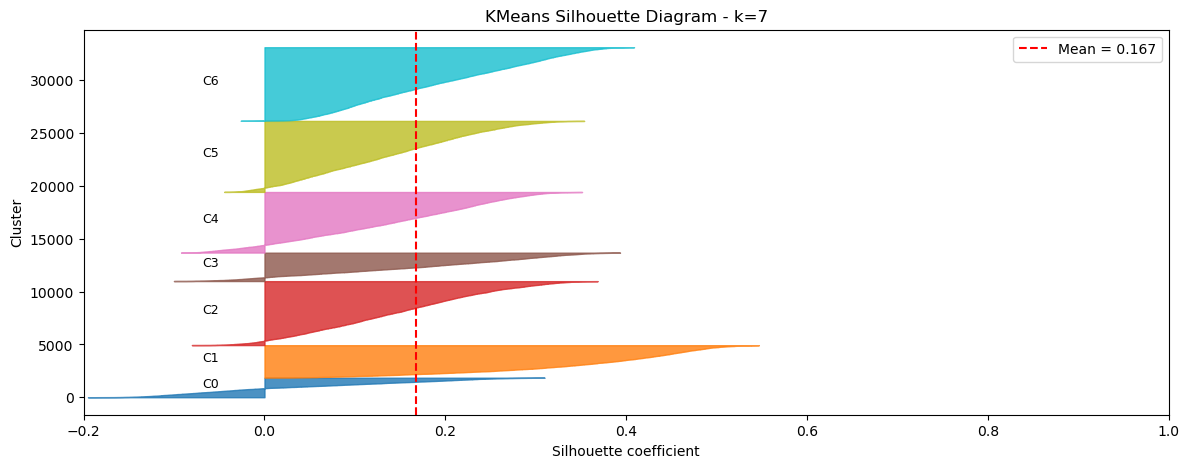

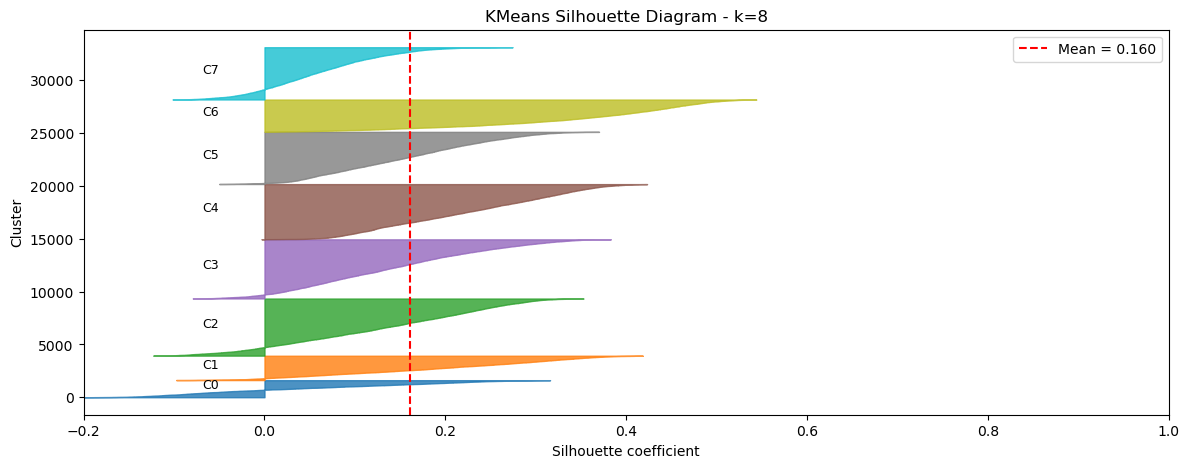

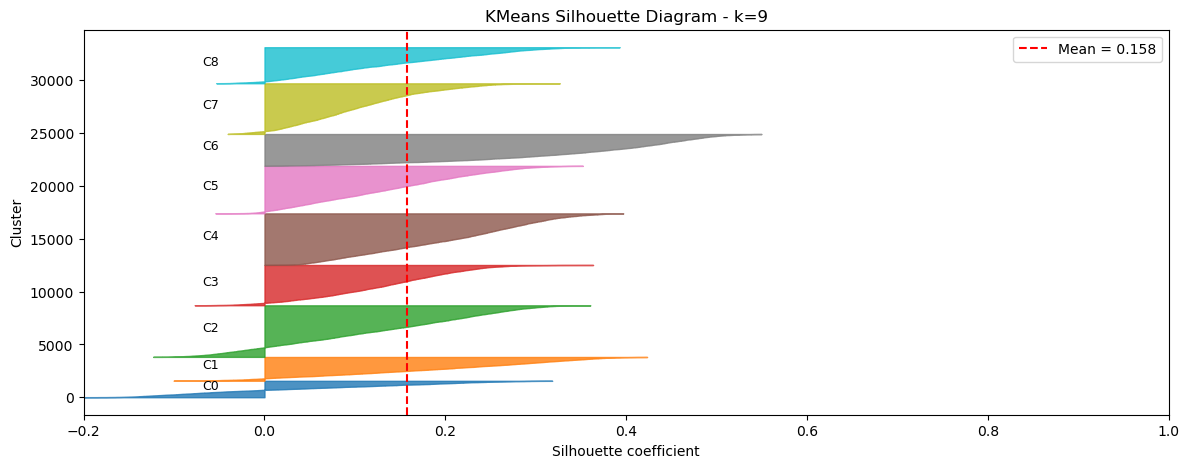

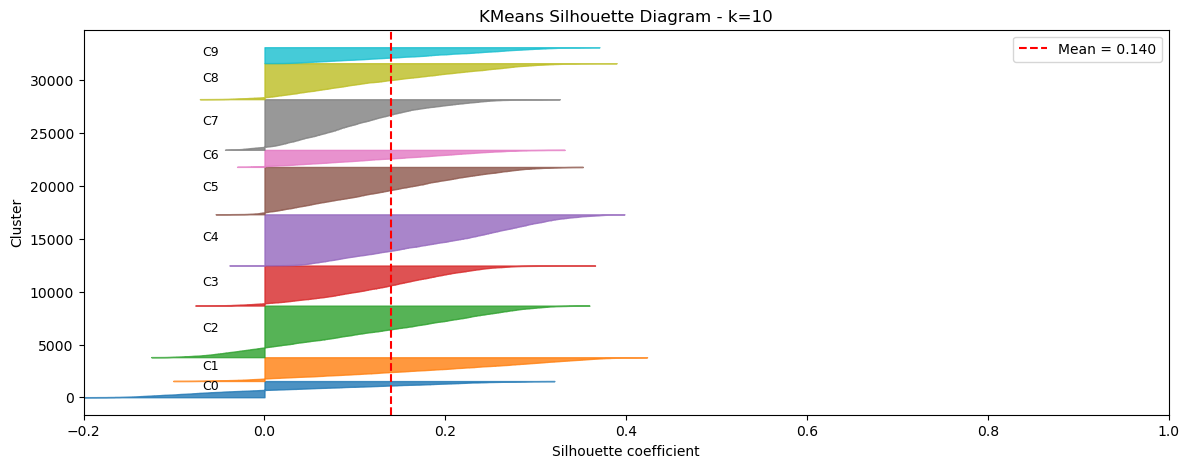

In [51]:
for k in [6, 7, 8, 9, 10]:
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = experimental_kmeans.fit_predict(X_scaled)

    score = plot_silhouette(
        X_scaled,
        labels,
        title=f"KMeans Silhouette Diagram - k={k}"
    )

    print(f"k={k} | silhouette={score:.4f}")

In [79]:
kmeans = KMeans(n_clusters= 8, random_state=0, n_init='auto').fit(X_scaled)
dataset['cluster_kmeans'] = kmeans.predict(X_scaled)


In [80]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
0    6584
4    5895
1    5427
2    4145
7    3943
3    3026
5    2348
6    1670
Name: count, dtype: int64

In [81]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [82]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7
customer_age,63.563335,58.151281,35.866586,57.287839,62.094487,58.465503,59.015569,41.180573
number_complaints,0.568348,0.651741,0.514355,1.064111,0.847159,0.892675,0.937126,2.404261
total_children,1.732685,1.927584,1.376116,0.556510,1.423919,6.942930,1.573054,2.537154
years_tenure,14.463092,10.417542,6.442943,8.895902,11.692621,13.569421,11.494012,9.170682
distinct_stores_visited,2.489520,3.544131,3.307117,1.443820,4.690925,3.298552,3.674251,2.377631
percentage_of_products_bought_promotion,0.163219,0.133371,0.302869,0.260327,0.650322,0.203641,0.438142,0.446041
perc_spend_vegetables,0.030416,0.127456,0.025965,0.007844,0.022977,0.022946,0.055593,0.019341
perc_spend_meat_fish,0.054641,0.015177,0.055977,0.076142,0.063790,0.078715,0.190540,0.067891
perc_spend_tech_entertainment,0.077651,0.110797,0.088923,0.495410,0.074365,0.152810,0.159774,0.084133
perc_spend_hygiene,0.033410,0.096718,0.031680,0.011049,0.030480,0.025974,0.085077,0.029977


In [83]:
numeric_cols = dataset.select_dtypes(include='number')

numeric_cols = numeric_cols.drop(
    ['kids_home', 
    'teens_home', 
    'year_first_transaction', 
    'lifetime_spend_meat',  
    'lifetime_spend_fish',
    'lifetime_spend_nonalcohol_drinks',
    'latitude',
    'longitude'], axis = 1)

numeric_cols.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7
customer_age,63.563335,58.151281,35.866586,57.287839,62.094487,58.465503,59.015569,41.180573
total_children,1.732685,1.927584,1.376116,0.556510,1.423919,6.942930,1.573054,2.537154
years_tenure,14.463092,10.417542,6.442943,8.895902,11.692621,13.569421,11.494012,9.170682
distinct_stores_visited,2.489520,3.544131,3.307117,1.443820,4.690925,3.298552,3.674251,2.377631
number_complaints,0.568348,0.651741,0.514355,1.064111,0.847159,0.892675,0.937126,2.404261
typical_hour,10.826549,12.331491,13.678166,17.399868,13.915522,10.164395,13.071257,10.958915
lifetime_total_distinct_products,174.696689,104.192003,146.650181,109.859551,157.583376,297.520869,150.179641,97.782399
percentage_of_products_bought_promotion,0.163219,0.133371,0.302869,0.260327,0.650322,0.203641,0.438142,0.446041
lifetime_spend_groceries,22121.222357,9614.931085,18734.782871,8154.663913,19780.461238,24960.186116,3743.653293,14482.087243
lifetime_spend_vegetables,718.097053,1749.638474,553.710253,177.610707,421.967430,801.327087,448.834132,347.689576


In [84]:
experimental_hierarchical = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(X_scaled)

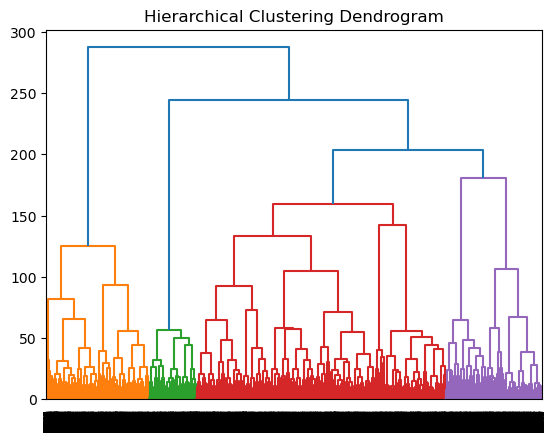

In [85]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(experimental_hierarchical, truncate_mode="level", p=50)
plt.show()


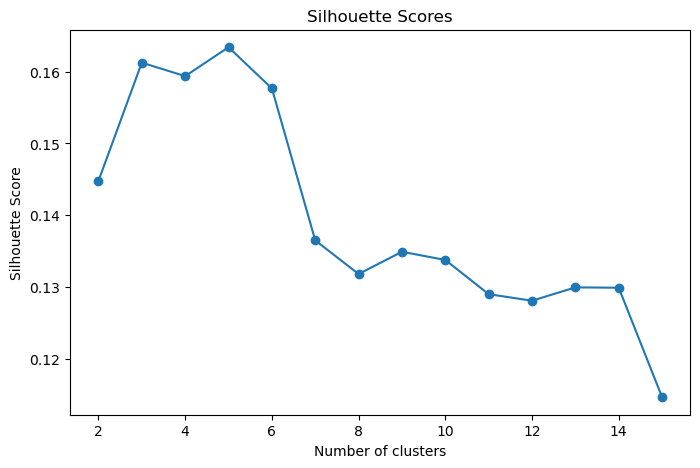

In [86]:
scores = []

for k in range(2,K_range+1):
    experimental_hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = experimental_hierarchical.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [88]:
dataset['cluster_agglomerative'] = AgglomerativeClustering(linkage='ward', n_clusters=8).fit_predict(X_scaled)

In [89]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'year_first_transaction',
       'years_tenure', 'distinct_stores_visited', 'number_complaints',
       'typical_hour', 'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_ou

In [90]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 40 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_age                             33038 non-null  int64  
 3   education_level                          33038 non-null  object 
 4   kids_home                                33038 non-null  int64  
 5   teens_home                               33038 non-null  int64  
 6   total_children                           33038 non-null  int64  
 7   year_first_transaction                   33038 non-null  int64  
 8   years_tenure                             33038 non-null  int64  
 9   distinct_stores_visited                  33038 non-null  int64  
 10  number_complaints                        33038 non-

In [92]:
pd.DataFrame(
    confusion_matrix(
        dataset['cluster_kmeans'],
        dataset['cluster_agglomerative']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 8)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 8)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster
K-Means 0 Cluster,1028,73,55,1645,250,3216,0,317
K-Means 1 Cluster,5316,55,0,23,0,8,6,19
K-Means 2 Cluster,465,28,73,340,179,510,0,2550
K-Means 3 Cluster,1,1,2926,33,5,26,0,34
K-Means 4 Cluster,26,23,3,4065,48,56,2,1672
K-Means 5 Cluster,1,95,1,76,2138,24,0,13
K-Means 6 Cluster,5,46,37,564,3,226,592,197
K-Means 7 Cluster,51,3361,37,212,91,54,1,136


In [95]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    dataset['cluster_kmeans'],
    dataset['cluster_agglomerative']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.504


In [96]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled)


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


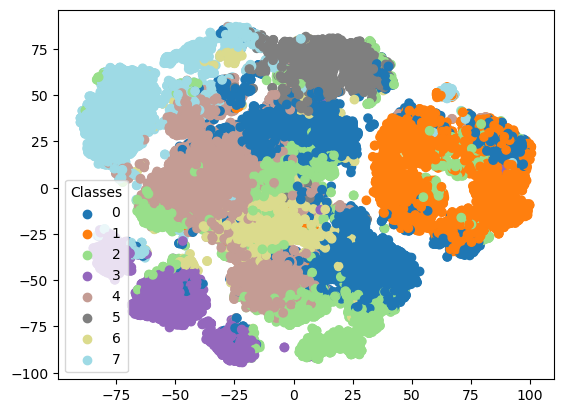

In [97]:
visualize_dimensionality_reduction(tsne_transformation, dataset['cluster_kmeans'])    


In [98]:
umap = UMAP(n_neighbors=50, random_state=0)



umap_transformation = umap.fit_transform(X_scaled)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


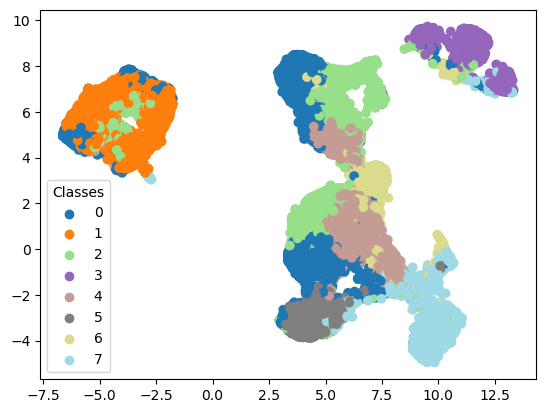

In [99]:
visualize_dimensionality_reduction(umap_transformation, dataset['cluster_kmeans'])